# 训练阶段

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from YOLOV1 import YOLOV1, YOLOLoss
from data import (
    VOCDataset,
    NMS,
    ALL_CLASS,
    IMAGE_SIZE,
    img_path,
    annotations_path,
    process_predict_data,
)
from torch.utils.data import DataLoader
from tqdm import tqdm
import time
import matplotlib.pyplot as plt
import cv2

# 训练模型
def train():
    train_loader = DataLoader(
        VOCDataset(img_path=img_path, annotations_path=annotations_path),
        batch_size=8,
        shuffle=True,
        num_workers=4,
    )
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = len(ALL_CLASS)
    model = YOLOV1(num_classes=num_classes).to(device)
    model.init_weight()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
    # optimizer = optim.Adam(model.parameters(), momentum=0.9, lr=0.01)
    criterion = YOLOLoss(num_classes=num_classes)
    # 设置学习率下降策略
    scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[200], gamma=0.1)

    epochs = 300
    epoch_losses = []
    for epoch in range(epochs):
        model.train()
        start_time = time.time()
        epoch_loss = 0
        epoch_xy = 0
        epoch_wh = 0
        epoch_conf = 0
        epoch_class = 0
        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)
            # print(images.shape, labels.shape) # torch.Size([32, 3, 448, 448]) torch.Size([32, 7, 7, 30])
            predictions = model(images)
            # print(predictions.shape) # torch.Size([32, 7, 7, 30])
            # print(predictions.requires_grad) #True
            # print(labels.requires_grad) # False
            loss, xy, wh, conf, cls = criterion(predictions, labels)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            epoch_loss += loss.item()
            epoch_xy += xy.item()
            epoch_wh += wh.item()
            epoch_conf += conf.item()
            epoch_class += cls.item()
        scheduler.step()
        epoch_losses.append(epoch_loss / len(train_loader))
        print(
            f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss / len(train_loader):.4f} | XY: {epoch_xy / len(train_loader):.4f} | WH: {epoch_wh / len(train_loader):.4f} | Conf: {epoch_conf / len(train_loader):.4f} | Class: {epoch_class / len(train_loader):.4f}. Time: {time.time() - start_time:.2f}s"
        )
        if (epoch + 1) % 10 == 0:
            torch.save(model.state_dict(), f"./model/yolov1_epoch_{epoch+1}.pth")
        # Save latest model every epoch so we can test it immediately
        torch.save(model.state_dict(), "./model/yolov1.pth")
    torch.save(model.state_dict(), "./model/yolov1.pth")

    # 绘制损失曲线
    plt.plot(epoch_losses, label="Training Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Loss")
    plt.show()

# 测试模型
def evaluate():
    test_loader = DataLoader(
        VOCDataset(img_path=img_path, annotations_path=annotations_path, train=False),
        batch_size=32,
        shuffle=True,
        num_workers=4,
    )
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = len(ALL_CLASS)
    model = YOLOV1(num_classes=num_classes).to(device)
    model.load_state_dict(torch.load("./model/yolov1.pth"))
    model.eval()
    criterion = YOLOLoss(num_classes=num_classes)

    all_loss = []
    xy_loss = []
    wh_loss = []
    conf_loss = []
    cls_loss = []
    with torch.no_grad():
        for images, labels in tqdm(test_loader):
            images, labels = images.to(device), labels.to(device)
            predictions = model(images)
            loss, xy, wh, conf, cls = criterion(predictions, labels)
            all_loss.append(loss.item())
            xy_loss.append(xy.item())
            wh_loss.append(wh.item())
            conf_loss.append(conf.item())
            cls_loss.append(cls.item())

    # 绘制损失曲线
    plt.plot(all_loss, label="Training Loss", color="red")
    plt.plot(xy_loss, label="XY Loss", color="green")
    plt.plot(wh_loss, label="WH Loss", color="blue")
    plt.plot(conf_loss, label="Conf Loss", color="orange")
    plt.plot(cls_loss, label="Class Loss", color="purple")
    plt.xlabel("Batch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.show()


100%|██████████| 501/501 [08:22<00:00,  1.00s/it]


Epoch 1/300 | Loss: 5.0683 | XY: 2.5676 | WH: 1.0489 | Conf: 0.8685 | Class: 0.5834. Time: 502.75s


100%|██████████| 501/501 [07:49<00:00,  1.07it/s]


Epoch 2/300 | Loss: 3.6804 | XY: 2.1581 | WH: 0.6735 | Conf: 0.4560 | Class: 0.3928. Time: 469.97s


100%|██████████| 501/501 [07:49<00:00,  1.07it/s]


...

Epoch 298/300 | Loss: 0.3796 | XY: 0.0667 | WH: 0.0402 | Conf: 0.1912 | Class: 0.0815. Time: 449.92s


100%|██████████| 501/501 [07:29<00:00,  1.11it/s]


Epoch 299/300 | Loss: 0.3840 | XY: 0.0687 | WH: 0.0413 | Conf: 0.1924 | Class: 0.0816. Time: 449.74s


100%|██████████| 501/501 [07:30<00:00,  1.11it/s]


Epoch 300/300 | Loss: 0.3787 | XY: 0.0663 | WH: 0.0399 | Conf: 0.1907 | Class: 0.0817. Time: 450.38s


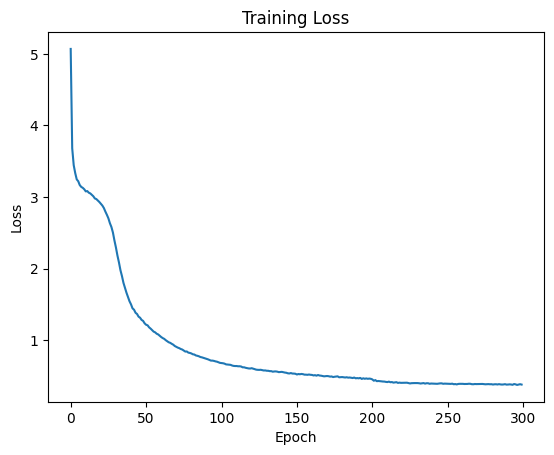

In [6]:
train()

100%|██████████| 32/32 [08:13<00:00, 15.43s/it]  


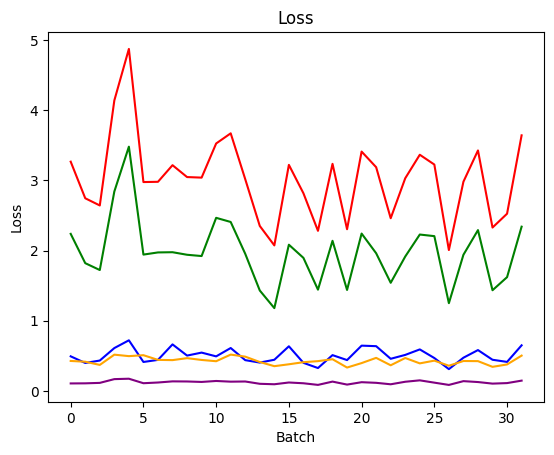

In [7]:
evaluate()


In [26]:
def draw_image(path):
    img = cv2.imread(path)
    img = process_predict_data(img)
    tensor_img = torch.tensor(img, dtype=torch.float32) / 255.0  # (448, 448, 3)
    tensor_img = tensor_img.permute(2, 0, 1)  # (3, 448, 448)
    tensor_img = tensor_img.unsqueeze(0)  # (1, 3, 448, 448)
    model = YOLOV1()
    model.load_state_dict(torch.load("./model/yolov1.pth"))
    model.eval()

    with torch.no_grad():
        labels = model(tensor_img)
        # print(labels.shape) # torch.Size([1, 7, 7, 30])
        boxes = labels.squeeze(0)  # (7, 7, 30)
        # 打印完整张量，不省略
        # with torch.no_grad():
        #     torch.set_printoptions(threshold=torch.inf)
        #     print(boxes)
        true_boxes = NMS(boxes)
        
        # 绘制预测框
        for box in true_boxes:
            x1, y1, x2, y2, conf, cls = box
            cv2.rectangle(img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
            cv2.putText(img, f"{ALL_CLASS[int(cls)]}: {conf:.2f}", (int(x1), int(y1)-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

        # 显示图像
        cv2.imshow("Image", img)
        cv2.waitKey(0)
        cv2.destroyAllWindows()


draw_image("D:\my code\yolo_data\VOC2007\JPEGImages\\000269.jpg")
# draw_image("D:\my code\yolo_data\VOC2007\JPEGImages\\000005.jpg")

class_idx: tensor(8)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(15)
class_idx: tensor(11)
class_idx: tensor(19)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(15)
class_idx: tensor(17)
class_idx: tensor(0)
class_idx: tensor(14)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(15)
class_idx: tensor(16)
class_idx: tensor(0)
class_idx: tensor(14)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(16)
class_idx: tensor(1)
class_idx: tensor(5)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(14)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(15)
class_idx: tensor(18)
class_idx: tensor(19)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(0)
class_idx: tensor(0)